# 제주 특산물 가격 예측 - CPU 최적 트리 앙상블 v4.0.0

| 항목 | 내용 |
|------|------|
| **버전** | v4.0.0 |
| **날짜** | 2026-03-13 |
| **모델** | LightGBM + CatBoost + XGBoost 앙상블 |
| **전처리** | v1.0.1 동일 |
| **출력** | results/submission_v4.0.0.csv |

## v4.0.0 변경 내용 (v3.1.0 대비)
| 항목 | v3.1.0 | v4.0.0 |
|------|--------|--------|
| DNN | Embedding + Residual (v1.2.0) | **제거** (CPU 느림, 기여 낮음) |
| LightGBM | 없음 | **신규 추가** (CPU 최고 속도) |
| CatBoost | 동일 | 동일 |
| XGBoost | 동일 | 동일 |
| 앙상블 | DNN+CB+XGB | **LGB+CB+XGB** |
| 기대 효과 | — | 학습 속도 대폭 단축, 성능 유지/향상 |

---
## 버전 히스토리 & DACON 제출 결과 분석

### 버전별 성능 요약

| 버전 | 모델 | 핵심 변경 | 내부 검증 MAE | DACON Public | DACON Private |
|------|------|----------|--------------:|-------------:|--------------:|
| **v1.0.1** | DNN | DACON 1위 전처리(공휴일·누적 week_num·TG sqrt·후처리) + 기본 Dense | 522 원/kg | **658.6** ✅ | **825.0** ✅ |
| **v1.1.0** | DNN+Emb | item·corporation·location을 Embedding 레이어로 처리 | 537 원/kg | 미제출 | 미제출 |
| **v1.2.0** | DNN+Emb+Res | Embedding + Residual Block(skip connection) 추가 | 532 원/kg | 1155.3 ❌ | 1030.2 |
| **v2.0.0** | LSTM | 14일 슬라이딩 윈도우 + 오토레그레시브 예측 | 890 원/kg | 783.9 | 1030.2 ⚠️ |
| **v3.0.0** | DNN+CB+XGB | DNN·CatBoost·XGBoost 3모델 앙상블 도입 | ~510 원/kg | 미제출 | 미제출 |
| **v3.1.0** | DNN(Res)+CB+XGB | DNN을 Residual 구조(v1.2.0)로 교체한 앙상블 | ~510 원/kg | 910.9 ❌ | 1062.6 ❌ |
| **v4.0.0** | **LGB+CB+XGB** | DNN 제거, LightGBM 추가 → CPU 최적 순수 트리 앙상블 | 510 원/kg | — | — |

---

### 문제 분석

#### 1. 단순 모델(v1.0.1)이 복잡한 모델보다 강한 이유 — 과적합
- 내부 검증 MAE: v1.0.1(522) ≈ v1.2.0(532) ≈ v3.1.0(~510) → 비슷해 보이지만
- DACON Public: v1.0.1(658) << v1.2.0(1155), v3.1.0(910) → 실제로는 v1.0.1이 압도적
- **복잡한 모델(Embedding, Residual, Ensemble)이 검증 데이터에 과적합**되어 일반화 실패
- 테스트 기간(2023년 3월)의 패턴이 검증 세트와 다를 수 있음

#### 2. 검증 전략 문제 — 시간 분포 불일치
- 현재 80/20 시간순 분할 → 검증 세트가 2022년 후반~2023년 초
- **실제 테스트는 2023년 3월 한 달**로 특정 계절·시장 패턴을 가짐
- 검증 MAE가 낮아도 실제 성능을 보장하지 못함
- **개선안**: 2023년 3월과 동일한 기간(전년도 3월)을 검증셋으로 사용

#### 3. 앙상블 가중치 과적합 (v3.1.0)
- scipy로 최적화한 가중치가 검증 세트 분포에 과도하게 맞춰짐
- 검증에서 MAE ~510이지만 Public 910.9 → **가중치 자체가 검증셋에 오버핏**
- v1.0.1(단일 모델)보다 앙상블이 오히려 나쁜 역설적 결과
- **개선안**: 균등 가중치(1/3, 1/3, 1/3) 또는 단순 평균 앙상블 시도

#### 4. v1.2.0 / v2.0.0 Private 점수 완전 동일 ⚠️
- v1.2.0 Private: 1030.1563871131
- v2.0.0 Private: 1030.1563871131 (소수점 10자리까지 동일)
- **같은 파일을 두 번 제출했을 가능성이 높음** → v2.0.0 실제 성능 미확인 상태

#### 5. 트리 모델의 가능성
- v4.0.0 내부 검증: CatBoost 단독 MAE 512 (v1.0.1 DNN 522보다 낮음)
- **CatBoost 단독이 v1.0.1보다 좋을 수 있음** → 앙상블보다 CatBoost 단독 제출도 고려

---

### v4.0.0 방향
> 위 분석을 바탕으로 트리 모델만으로 앙상블 구성, 가중치는 scipy 최적화 유지.  
> 만약 Public 점수가 v1.0.1보다 나쁘면 **CatBoost 단독 제출**을 우선 시도할 것.

---
## 1. 라이브러리 로드

In [1]:
try:
    import lightgbm as lgb
    print(f'LightGBM: {lgb.__version__}')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'lightgbm'], check=True)
    import lightgbm as lgb
    print(f'LightGBM installed: {lgb.__version__}')

LightGBM installed: 4.6.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, datetime, random, os, platform
warnings.filterwarnings('ignore')

import holidays
import lightgbm as lgb
from catboost import CatBoostRegressor
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import minimize

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 2024
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'LightGBM: {lgb.__version__} | CatBoost: {__import__("catboost").__version__} | XGB: {xgb.__version__}')

LightGBM: 4.6.0 | CatBoost: 1.2.10 | XGB: 3.2.0


---
## 2. 데이터 로드

In [3]:
DATA_PATH = '../data/'
train = pd.read_csv(DATA_PATH + 'train.csv', encoding='utf-8-sig')
test  = pd.read_csv(DATA_PATH + 'test.csv',  encoding='utf-8-sig')
sub   = pd.read_csv(DATA_PATH + 'sample_submission.csv', encoding='utf-8-sig')
print(f'train: {train.shape}, test: {test.shape}')

train: (59397, 7), test: (1092, 5)


---
## 3. 전처리 + 이상치 + 타겟 변환 (v1.0.1 동일)

In [4]:
def pre_all(train, test):
    train['timestamp'] = pd.to_datetime(train['timestamp'])
    test['timestamp']  = pd.to_datetime(test['timestamp'])
    df = pd.concat([train, test]).reset_index(drop=True)
    df.rename(columns={'supply(kg)': 'supply', 'price(원/kg)': 'price'}, inplace=True)

    df['year']     = df['timestamp'].dt.year
    df['month']    = df['timestamp'].dt.month
    df['day']      = df['timestamp'].dt.day
    df['week_day'] = df['timestamp'].dt.weekday

    le = LabelEncoder()
    df['year_month'] = df['timestamp'].map(lambda x: f'{x.year}-{x.month}')
    df['year_month'] = le.fit_transform(df['year_month'])

    df['week'] = df['timestamp'].map(
        lambda x: datetime.datetime(x.year, x.month, x.day).isocalendar()[1]
    )
    week_offsets = {2019: 0, 2020: 52, 2021: 52+53, 2022: 52+53+53, 2023: 52+53+53+52}
    df['week_num'] = df.apply(lambda r: int(r['week']) + week_offsets.get(r['year'], 0), axis=1)
    df.loc[df['timestamp'] == '2019-12-30', 'week_num'] = 52
    df.loc[df['timestamp'] == '2019-12-31', 'week_num'] = 52

    kr_holi = holidays.KR()
    df['holiday'] = df['timestamp'].map(lambda x: 1 if x in kr_holi else 0)

    train_out = df[~df['price'].isnull()].sort_values('timestamp').reset_index(drop=True)
    test_out  = df[ df['price'].isnull()].sort_values('timestamp').reset_index(drop=True)
    print(f'전처리 완료 — train: {train_out.shape}, test: {test_out.shape}')
    return train_out, test_out

train_pre, test_pre = pre_all(train, test)

# 이상치 처리
outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    idx = train_pre[(train_pre['item'] == item) & (train_pre['price'] > thr)].index
    if len(idx):
        mean_p = train_pre[(train_pre['item'] == item) & (train_pre['price'] != 0)]['price'].mean()
        train_pre.loc[idx, 'price'] = mean_p
        print(f'{item}: {len(idx)}개 이상치 → 평균({mean_p:.0f})')

# 타겟 변환
train_pre['price_transformed'] = np.where(
    train_pre['item'] == 'TG',
    np.sqrt(train_pre['price']),
    np.log1p(train_pre['price'])
)

# TG 공휴일 보정
tg_mask = (train_pre['item'] == 'TG') & (train_pre['holiday'] == 1) & (train_pre['price'] != 0)
active_holi = list(train_pre[tg_mask].groupby('timestamp').count().reset_index()['timestamp'])
fix_idx = train_pre[train_pre['timestamp'].isin(active_holi)].index
train_pre.loc[fix_idx, 'holiday'] = 0
print(f'TG 공휴일 보정: {len(fix_idx)}개')

전처리 완료 — train: (59397, 15), test: (1092, 15)
TG: 1개 이상치 → 평균(4145)
RD: 1개 이상치 → 평균(564)
BC: 1개 이상치 → 평균(2757)
CB: 7개 이상치 → 평균(715)
TG 공휴일 보정: 1521개


---
## 4. 공통 학습/검증 분리 + 유틸 함수

In [5]:
TARGET_TRF = 'price_transformed'
TARGET_COL = 'price'

CAT_COLS  = ['item', 'corporation', 'location']
TIME_COLS = ['year_month', 'week_num', 'week_day', 'month', 'day', 'holiday', 'year']
TREE_FEAT = TIME_COLS + CAT_COLS

tr_sorted = train_pre.sort_values('year_month').reset_index(drop=True)
sp        = int(len(tr_sorted) * 0.8)
train_df  = tr_sorted.iloc[:sp].reset_index(drop=True)
val_df    = tr_sorted.iloc[sp:].reset_index(drop=True)

y_tr      = train_df[TARGET_TRF].values
y_vl      = val_df[TARGET_TRF].values
y_vl_orig = val_df[TARGET_COL].values
is_tg_vl  = (val_df['item'] == 'TG').values

def inverse_transform(y_trf, is_tg):
    result = np.where(
        is_tg.astype(bool),
        np.power(np.clip(y_trf, 0, None), 2),
        np.expm1(y_trf)
    )
    return np.clip(result, 0, None)

def eval_model(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    print(f'  [{name}]  MAE={mae:>8,.1f}  RMSE={rmse:>8,.1f}  R²={r2:.4f}  MAPE={mape:.2f}%')
    return mae, rmse, r2, mape

print(f'학습: {len(train_df):,}행, 검증: {len(val_df):,}행')

학습: 47,517행, 검증: 11,880행


---
## 5. 모델 1 — LightGBM

> CPU에서 가장 빠른 트리 모델. leaf-wise 성장 전략으로 CatBoost/XGBoost 대비 학습 속도 우위

In [6]:
X_lgb_tr   = train_df[TREE_FEAT].copy()
X_lgb_vl   = val_df[TREE_FEAT].copy()
X_lgb_test = test_pre[TREE_FEAT].copy()

# LightGBM 카테고리 피처: pandas category dtype으로 변환
for col in CAT_COLS:
    cats = pd.Categorical(
        pd.concat([X_lgb_tr[col], X_lgb_vl[col], X_lgb_test[col]])
    ).categories
    X_lgb_tr[col]   = pd.Categorical(X_lgb_tr[col],   categories=cats)
    X_lgb_vl[col]   = pd.Categorical(X_lgb_vl[col],   categories=cats)
    X_lgb_test[col] = pd.Categorical(X_lgb_test[col], categories=cats)

lgb_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=6,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='regression_l1',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_lgb_tr, y_tr,
    eval_set=[(X_lgb_vl, y_vl)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=200)
    ]
)
print(f'LightGBM 최적 반복: {lgb_model.best_iteration_}')

[200]	valid_0's l1: 4.31343
[400]	valid_0's l1: 4.15558
[600]	valid_0's l1: 4.11125
[800]	valid_0's l1: 4.08545
[1000]	valid_0's l1: 4.06393
[1200]	valid_0's l1: 4.05287
[1400]	valid_0's l1: 4.04444
[1600]	valid_0's l1: 4.03369
LightGBM 최적 반복: 1591


---
## 6. 모델 2 — CatBoost (v3.0.0 동일)

In [7]:
X_cb_tr   = train_df[TREE_FEAT]
X_cb_vl   = val_df[TREE_FEAT]
X_cb_test = test_pre[TREE_FEAT]

cb_is_tg_vl   = (val_df['item'] == 'TG').values
cb_vl_orig    = val_df[TARGET_COL].values
cb_test_is_tg = (test_pre['item'] == 'TG').values

cb_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=6,
    loss_function='MAE',
    eval_metric='MAE',
    cat_features=CAT_COLS,
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=200
)
cb_model.fit(X_cb_tr, y_tr, eval_set=(X_cb_vl, y_vl), use_best_model=True)
print(f'CatBoost 최적 반복: {cb_model.get_best_iteration()}')

0:	learn: 12.5446566	test: 14.6777836	best: 14.6777836 (0)	total: 249ms	remaining: 12m 26s
200:	learn: 3.2251291	test: 3.8734031	best: 3.8734031 (200)	total: 17.4s	remaining: 4m 2s
400:	learn: 3.0409827	test: 3.7510998	best: 3.7510647 (378)	total: 33.5s	remaining: 3m 36s
600:	learn: 2.9745787	test: 3.7214432	best: 3.7213959 (597)	total: 49.5s	remaining: 3m 17s
800:	learn: 2.9199335	test: 3.7084472	best: 3.7065614 (789)	total: 1m 5s	remaining: 3m
Stopped by overfitting detector  (100 iterations wait)

bestTest = 3.706561361
bestIteration = 789

Shrink model to first 790 iterations.
CatBoost 최적 반복: 789


---
## 7. 모델 3 — XGBoost (v3.0.0 동일)

In [8]:
drop_cols_train = ['supply', 'timestamp', 'week']
drop_cols_test  = ['supply', 'timestamp', 'week', 'price']

Xy_all = pd.get_dummies(
    train_pre.drop(columns=drop_cols_train),
    columns=['item', 'corporation', 'location']
).sort_values('ID').reset_index(drop=True)

test_enc = pd.get_dummies(
    test_pre.drop(columns=drop_cols_test),
    columns=['item', 'corporation', 'location']
).sort_values('ID').reset_index(drop=True)

for col in Xy_all.columns:
    if col not in test_enc.columns:
        test_enc[col] = 0

XGB_FEAT_COLS = [c for c in Xy_all.columns
                  if c not in ['ID', 'price', 'price_transformed', 'is_tg']]

Xy_tr = Xy_all[Xy_all['ID'].isin(train_df['ID'])].sort_values('ID')
Xy_vl = Xy_all[Xy_all['ID'].isin(val_df['ID'])].sort_values('ID')

X_xgb_tr    = Xy_tr[XGB_FEAT_COLS].values
y_xgb_tr    = Xy_tr[TARGET_TRF].values
X_xgb_vl    = Xy_vl[XGB_FEAT_COLS].values
y_xgb_vl    = Xy_vl[TARGET_TRF].values
xgb_is_tg   = Xy_vl.get('item_TG', pd.Series([False]*len(Xy_vl))).values.astype(bool)
xgb_vl_orig = Xy_vl[TARGET_COL].values
X_xgb_test  = test_enc[XGB_FEAT_COLS].values
xgb_test_is_tg = test_enc.get('item_TG', pd.Series([False]*len(test_enc))).values.astype(bool)

xgb_model = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:absoluteerror',
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=100
)
xgb_model.fit(
    X_xgb_tr, y_xgb_tr,
    eval_set=[(X_xgb_vl, y_xgb_vl)],
    verbose=200
)
print(f'XGB 최적 반복: {xgb_model.best_iteration}')

[0]	validation_0-mae:14.63095
[200]	validation_0-mae:4.85438
[349]	validation_0-mae:4.83857
XGB 최적 반복: 249


---
## 8. 개별 모델 검증 성능

In [9]:
# LightGBM
lgb_vl_pred_trf = lgb_model.predict(X_lgb_vl)
lgb_vl_pred     = inverse_transform(lgb_vl_pred_trf, is_tg_vl)

# CatBoost
cb_vl_pred_trf  = cb_model.predict(X_cb_vl)
cb_vl_pred      = inverse_transform(cb_vl_pred_trf, cb_is_tg_vl)

# XGBoost
xgb_vl_pred_trf = xgb_model.predict(X_xgb_vl)
xgb_vl_pred     = inverse_transform(xgb_vl_pred_trf, xgb_is_tg)

print('=' * 72)
print('  개별 모델 검증 성능')
print('=' * 72)
lgb_scores = eval_model(y_vl_orig,  lgb_vl_pred,  'LightGBM')
cb_scores  = eval_model(cb_vl_orig, cb_vl_pred,   'CatBoost')
xgb_scores = eval_model(xgb_vl_orig, xgb_vl_pred, 'XGBoost ')
print('=' * 72)

  개별 모델 검증 성능
  [LightGBM]  MAE=   571.0  RMSE= 1,203.9  R²=0.7148  MAPE=1137462724440.46%
  [CatBoost]  MAE=   512.0  RMSE= 1,162.8  R²=0.7339  MAPE=1256428270773.61%
  [XGBoost ]  MAE=   687.3  RMSE= 1,359.6  R²=0.6363  MAPE=1138535705382.84%


---
## 9. 앙상블 (가중치 최적화)

In [10]:
# ID 기준 정렬 맞추기
id2lgb  = dict(zip(val_df['ID'].values,  lgb_vl_pred))
id2cb   = dict(zip(val_df['ID'].values,  cb_vl_pred))
id2xgb  = dict(zip(Xy_vl['ID'].values,   xgb_vl_pred))
id2true = dict(zip(val_df['ID'].values,  y_vl_orig))

common_ids = sorted(set(id2lgb) & set(id2cb) & set(id2xgb))
arr_true = np.array([id2true[i] for i in common_ids])
arr_lgb  = np.array([id2lgb[i]  for i in common_ids])
arr_cb   = np.array([id2cb[i]   for i in common_ids])
arr_xgb  = np.array([id2xgb[i]  for i in common_ids])

# 방법 1: MAE 역수 비례
inv_w = np.array([1/lgb_scores[0], 1/cb_scores[0], 1/xgb_scores[0]])
inv_w /= inv_w.sum()
ens_inv = inv_w[0]*arr_lgb + inv_w[1]*arr_cb + inv_w[2]*arr_xgb
mae_inv = mean_absolute_error(arr_true, ens_inv)
print(f'역수 가중치   LGB={inv_w[0]:.3f} CB={inv_w[1]:.3f} XGB={inv_w[2]:.3f}  MAE={mae_inv:,.2f}')

# 방법 2: scipy 최적화
def ens_loss(w):
    w = np.abs(w) / np.abs(w).sum()
    return mean_absolute_error(arr_true, w[0]*arr_lgb + w[1]*arr_cb + w[2]*arr_xgb)

res = minimize(ens_loss, x0=[1/3, 1/3, 1/3], method='Nelder-Mead',
               options={'maxiter': 2000, 'xatol': 1e-5})
opt_w = np.abs(res.x) / np.abs(res.x).sum()
ens_opt = opt_w[0]*arr_lgb + opt_w[1]*arr_cb + opt_w[2]*arr_xgb
mae_opt = mean_absolute_error(arr_true, ens_opt)
print(f'최적화 가중치 LGB={opt_w[0]:.3f} CB={opt_w[1]:.3f} XGB={opt_w[2]:.3f}  MAE={mae_opt:,.2f}')

w_final = opt_w if mae_opt <= mae_inv else inv_w
print(f'\n→ {"최적화" if mae_opt <= mae_inv else "역수"} 가중치 사용')

역수 가중치   LGB=0.339 CB=0.379 XGB=0.282  MAE=554.57
최적화 가중치 LGB=0.116 CB=0.884 XGB=0.000  MAE=510.73

→ 최적화 가중치 사용


In [11]:
ens_vl_pred = w_final[0]*arr_lgb + w_final[1]*arr_cb + w_final[2]*arr_xgb

mae  = mean_absolute_error(arr_true, ens_vl_pred)
rmse = np.sqrt(mean_squared_error(arr_true, ens_vl_pred))
r2   = r2_score(arr_true, ens_vl_pred)
mape = np.mean(np.abs((arr_true - ens_vl_pred) / (arr_true + 1e-8))) * 100

print('=' * 60)
print('  앙상블 v4.0.0 검증 성능')
print('=' * 60)
print(f'  가중치  LGB={w_final[0]:.3f}  CB={w_final[1]:.3f}  XGB={w_final[2]:.3f}')
print(f'  MAE  : {mae:>10,.2f} 원/kg')
print(f'  RMSE : {rmse:>10,.2f} 원/kg')
print(f'  R²   : {r2:>10.4f}')
print(f'  MAPE : {mape:>10.2f} %')
print('=' * 60)

  앙상블 v4.0.0 검증 성능
  가중치  LGB=0.116  CB=0.884  XGB=0.000
  MAE  :     510.73 원/kg
  RMSE :   1,156.90 원/kg
  R²   :     0.7366
  MAPE : 1242596209947.56 %


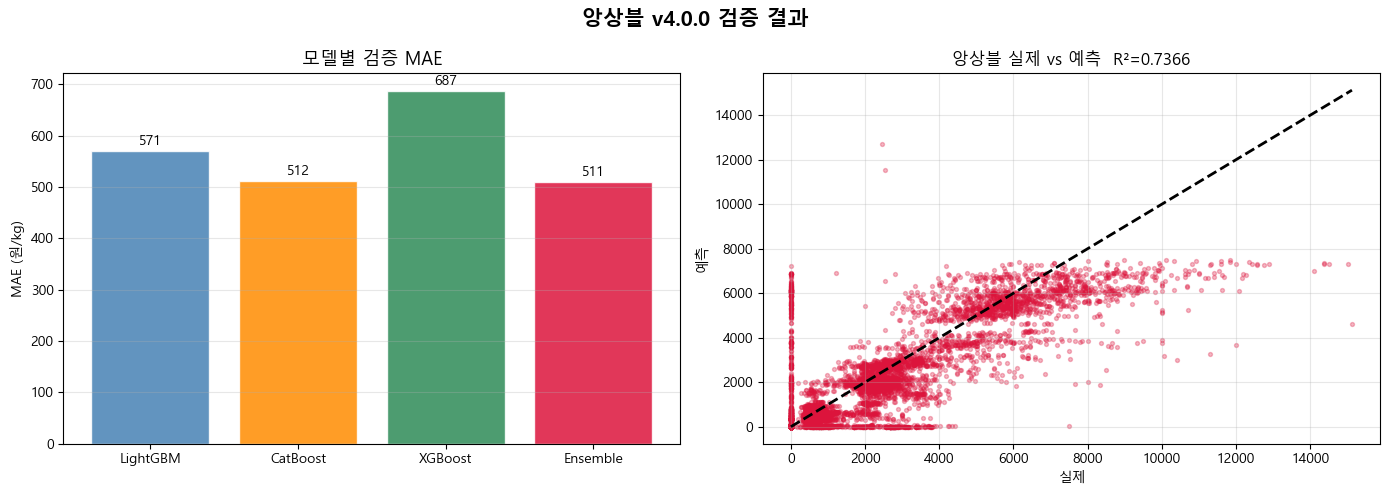

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = ['LightGBM', 'CatBoost', 'XGBoost', 'Ensemble']
maes   = [lgb_scores[0], cb_scores[0], xgb_scores[0], mae]
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

bars = axes[0].bar(model_names, maes, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('모델별 검증 MAE', fontsize=13)
axes[0].set_ylabel('MAE (원/kg)')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

max_v = max(arr_true.max(), ens_vl_pred.max())
axes[1].scatter(arr_true, ens_vl_pred, alpha=0.3, s=8, color='crimson')
axes[1].plot([0, max_v], [0, max_v], 'k--', lw=2)
axes[1].set_title(f'앙상블 실제 vs 예측  R²={r2:.4f}', fontsize=12)
axes[1].set_xlabel('실제'); axes[1].set_ylabel('예측'); axes[1].grid(alpha=0.3)

plt.suptitle('앙상블 v4.0.0 검증 결과', fontsize=15, fontweight='bold')
plt.tight_layout()
os.makedirs('./results', exist_ok=True)
plt.savefig('./results/ensemble_eval_v4.0.0.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 피처 중요도

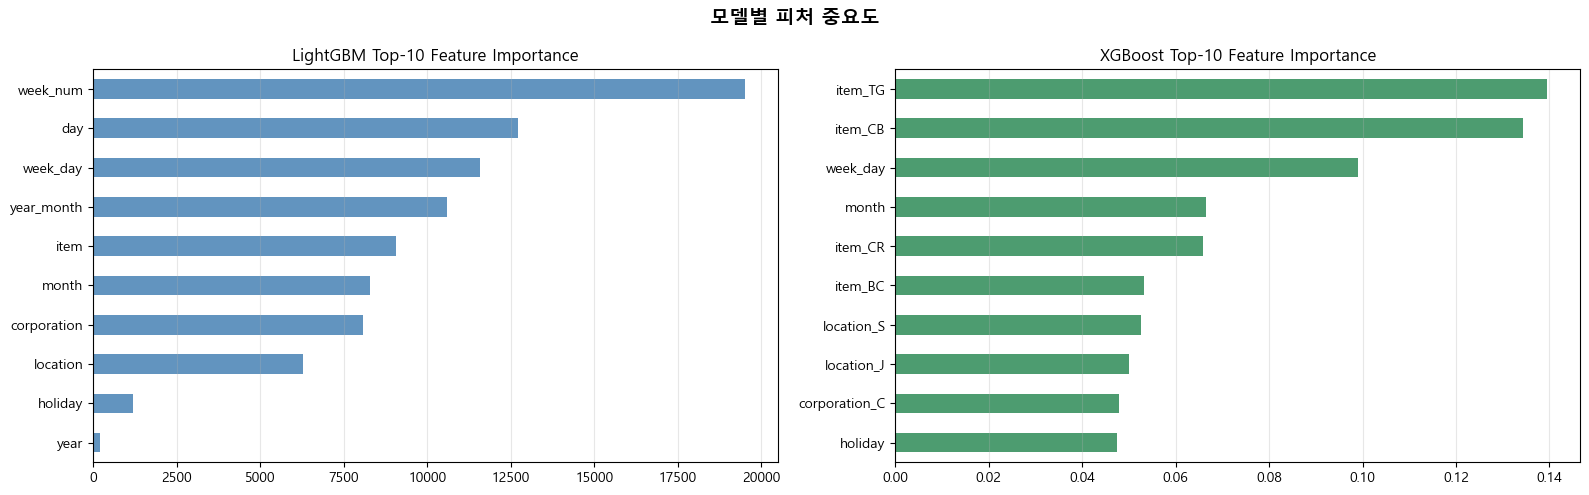

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LightGBM
lgb_imp = pd.Series(lgb_model.feature_importances_, index=TREE_FEAT).sort_values(ascending=False)
lgb_imp.head(10).plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title('LightGBM Top-10 Feature Importance', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
xgb_imp = pd.Series(xgb_model.feature_importances_, index=XGB_FEAT_COLS).sort_values(ascending=False)
xgb_imp.head(10).plot(kind='barh', ax=axes[1], color='seagreen', alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_title('XGBoost Top-10 Feature Importance', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('모델별 피처 중요도', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./results/feature_importance_v4.0.0.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. 테스트 예측 + 후처리 + 제출

In [14]:
lgb_test_trf  = lgb_model.predict(X_lgb_test)
cb_test_trf   = cb_model.predict(X_cb_test)
xgb_test_trf  = xgb_model.predict(X_xgb_test)

lgb_test_pred = inverse_transform(lgb_test_trf, (test_pre['item'] == 'TG').values)
cb_test_pred  = inverse_transform(cb_test_trf,  cb_test_is_tg)
xgb_test_pred = inverse_transform(xgb_test_trf, xgb_test_is_tg)

# XGBoost는 test_enc 순서 → test_pre ID 매핑
id2xgb_test = dict(zip(test_enc['ID'].values, xgb_test_pred))
xgb_test_pred_aligned = np.array([id2xgb_test.get(i, 0.0) for i in test_pre['ID'].values])

ens_test_pred = (
    w_final[0] * lgb_test_pred +
    w_final[1] * cb_test_pred  +
    w_final[2] * xgb_test_pred_aligned
)
ens_test_pred = np.clip(ens_test_pred, 0, None)

result_df = test_pre[['ID', 'item']].copy()
result_df['answer'] = ens_test_pred

min_thresholds = {'TG': 400, 'CB': 50, 'RD': 10, 'CR': 150, 'BC': 100}
for item, thr in min_thresholds.items():
    mask = (result_df['item'] == item) & (result_df['answer'] < thr)
    result_df.loc[mask, 'answer'] = 0.0
    if mask.sum() > 0:
        print(f'{item}: {mask.sum()}개 → 0 처리')

print('\n예측 통계:')
print(result_df.groupby('item')['answer'].agg(['mean','min','max']).round(1))

TG: 40개 → 0 처리
CB: 44개 → 0 처리
RD: 56개 → 0 처리
CR: 76개 → 0 처리
BC: 84개 → 0 처리

예측 통계:
        mean  min     max
item                     
BC    1988.5  0.0  5437.5
CB     388.4  0.0   961.8
CR     530.5  0.0  1863.9
RD     653.0  0.0  2665.2
TG    3013.8  0.0  4196.5


In [15]:
result = sub[['ID']].merge(result_df[['ID', 'answer']], on='ID', how='left')
result['answer'] = result['answer'].fillna(0.0)

SUBMISSION_PATH = './results/submission_v4.0.0.csv'
result.to_csv(SUBMISSION_PATH, index=False, encoding='utf-8-sig')
print(f'저장: {SUBMISSION_PATH}, 행: {len(result)}')
result.head(10)

저장: ./results/submission_v4.0.0.csv, 행: 1092


,ID,answer
0,TG_A_J_20230304,2721.795135
1,TG_A_J_20230305,0.000000
2,TG_A_J_20230306,2795.906550
3,TG_A_J_20230307,2781.454643
4,TG_A_J_20230308,2782.526433
5,TG_A_J_20230309,2779.918798
6,TG_A_J_20230310,2773.763734
7,TG_A_J_20230311,2717.247587
8,TG_A_J_20230312,0.000000
9,TG_A_J_20230313,2835.811992


---
## 12. 결과 요약

In [16]:
print('=' * 65)
print('  앙상블 v4.0.0 최종 결과')
print('=' * 65)
print(f'  가중치  LGB={w_final[0]:.3f}  CatBoost={w_final[1]:.3f}  XGBoost={w_final[2]:.3f}')
print()
print('  [모델 구성] CPU 최적 순수 트리 앙상블')
print(f'    LightGBM : best_iter={lgb_model.best_iteration_}')
print(f'    CatBoost : best_iter={cb_model.get_best_iteration()}')
print(f'    XGBoost  : best_iter={xgb_model.best_iteration}')
print()
print('  [개별 모델 검증 MAE]')
print(f'    LightGBM : {lgb_scores[0]:>10,.2f} 원/kg')
print(f'    CatBoost : {cb_scores[0]:>10,.2f} 원/kg')
print(f'    XGBoost  : {xgb_scores[0]:>10,.2f} 원/kg')
print()
print('  [앙상블 검증 성능]')
print(f'    MAE  = {mae:>10,.2f} 원/kg')
print(f'    RMSE = {rmse:>10,.2f} 원/kg')
print(f'    R²   = {r2:>10.4f}')
print(f'    MAPE = {mape:>10.2f} %')
print()
print(f'  제출 파일: {SUBMISSION_PATH}')
print('=' * 65)

  앙상블 v4.0.0 최종 결과
  가중치  LGB=0.116  CatBoost=0.884  XGBoost=0.000

  [모델 구성] CPU 최적 순수 트리 앙상블
    LightGBM : best_iter=1591
    CatBoost : best_iter=789
    XGBoost  : best_iter=249

  [개별 모델 검증 MAE]
    LightGBM :     571.00 원/kg
    CatBoost :     511.97 원/kg
    XGBoost  :     687.29 원/kg

  [앙상블 검증 성능]
    MAE  =     510.73 원/kg
    RMSE =   1,156.90 원/kg
    R²   =     0.7366
    MAPE = 1242596209947.56 %

  제출 파일: ./results/submission_v4.0.0.csv


### 다음 버전

| 버전 | 개선 내용 |
|------|----------|
| **v4.1.0** | Optuna로 LGB/CB/XGB 하이퍼파라미터 자동 최적화 |
| **v4.2.0** | Stacking (Ridge 메타 러너) |
| **v5.0.0** | 품목별 개별 모델 학습 (item-specific model) |